# Alvin PLC Northwinds SQL Data Report

## Overview:

This report is done to unveil hidden insights from a sample northwinds SQL database to provide data-driven solutions to further enahnce various business operations. 

## Table of Contents:

1. Loading the libraries
2. Importing the data
3. Exploring the data
4. Wrangling the data
5. Explortory Data Analysis

### Loading the Libraries

In [1]:
import pandas as pd
import numpy as np
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
## Importing the data from mssql server
# 1. Defining the connection string

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=DESKTOP-Q1ERR7S\SQLEXPRESS;"
    "DATABASE=Northwinds;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
)

# 2. create a cursor
cursor = conn.cursor()

# 3. reading data from a table
query = """
-- Wrangling the Northwinds data 
SELECT 
c.CustomerID,
o.OrderID,
C.CompanyName,
c.ContactName,
c.ContactTitle,
c.city,
c.country,
o.EmployeeID,
DATEDIFF(DAYOFYEAR, o.OrderDate, o.ShippedDate) AS order_processing_time_in_days,
o.Freight,
o.ShipCity AS destination_city,
o.ShipCountry AS destination_country,
e.EmployeeID, 
CONCAT(e.FirstName,e.LastName) AS employee_name,
e.title,
e.BirthDate,
e.HireDate,
e.city AS employee_city,
e.Country AS employee_country,
e.region AS employee_region,
t.TerritoryDescription,
od.UnitPrice * od.Quantity AS total_sales,
od.discount,
p.ProductName,
p.UnitsInStock - p.UnitsOnOrder AS net_free_stock,
p.ReorderLevel,
p.Discontinued,
r.RegionDescription,
s.CompanyName AS shipper
FROM dbo.Customers c
FULL OUTER JOIN dbo.Orders o
ON c.CustomerID = o.CustomerID
FULL OUTER JOIN dbo.Employees e
ON o.EmployeeID = e.EmployeeID
FULL OUTER JOIN dbo.EmployeeTerritories et
ON e.EmployeeID = et.EmployeeID
FULL OUTER JOIN dbo.Territories t
ON et.TerritoryID = t.TerritoryID
FULL OUTER JOIN dbo.[Order Details] od
ON o.OrderID = od.OrderID
FULL OUTER JOIN dbo.Products p
ON OD.ProductID = p.ProductID
FULL OUTER JOIN dbo.Region r
ON t.RegionID = r.RegionID
FULL OUTER JOIN Shippers s
ON o.ShipVia = s.ShipperID
FULL OUTER JOIN dbo.Suppliers sp
ON p.SupplierID = sp.SupplierID
WHERE c.CustomerID IS NOT NULL
ORDER BY CustomerID ASC;
"""
df = pd.read_sql(query, conn)
df

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Alvin\AppData\Local\Temp\ipykernel_6904\4089350155.py:6: SyntaxWarning: invalid escape sequence '\S'
  "SERVER=DESKTOP-Q1ERR7S\SQLEXPRESS;"
C:\Users\Alvin\AppData\Local\Temp\ipykernel_6904\4089350155.py:71: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CustomerID,OrderID,CompanyName,ContactName,ContactTitle,city,country,EmployeeID,order_processing_time_in_days,Freight,...,employee_region,TerritoryDescription,total_sales,discount,ProductName,net_free_stock,ReorderLevel,Discontinued,RegionDescription,shipper
0,ALFKI,10643.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,6.0,8.0,29.46,...,None,Phoenix ...,684.0,0.25,Rössle Sauerkraut,26.0,0.0,True,Western ...,Speedy Express
1,ALFKI,10643.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,6.0,8.0,29.46,...,None,Phoenix ...,378.0,0.25,Chartreuse verte,69.0,5.0,False,Western ...,Speedy Express
2,ALFKI,10643.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,6.0,8.0,29.46,...,None,Phoenix ...,24.0,0.25,Spegesild,95.0,0.0,False,Western ...,Speedy Express
3,ALFKI,10643.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,6.0,8.0,29.46,...,None,Scottsdale ...,684.0,0.25,Rössle Sauerkraut,26.0,0.0,True,Western ...,Speedy Express
4,ALFKI,10643.0,Alfreds Futterkiste,Maria Anders,Sales Representative,Berlin,Germany,6.0,8.0,29.46,...,None,Scottsdale ...,378.0,0.25,Chartreuse verte,69.0,5.0,False,Western ...,Speedy Express
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10126,WOLZA,10611.0,Wolski Zajazd,Zbyszek Piestrzeniewicz,Owner,Warszawa,Poland,6.0,7.0,80.65,...,None,Seattle ...,510.0,0.00,Camembert Pierrot,19.0,0.0,False,Western ...,United Package
10127,WOLZA,10374.0,Wolski Zajazd,Zbyszek Piestrzeniewicz,Owner,Warszawa,Poland,1.0,4.0,3.94,...,WA,Wilton ...,300.0,0.00,Gorgonzola Telino,-70.0,20.0,False,Eastern ...,Federal Shipping
10128,WOLZA,10374.0,Wolski Zajazd,Zbyszek Piestrzeniewicz,Owner,Warszawa,Poland,1.0,4.0,3.94,...,WA,Wilton ...,159.0,0.00,Escargots de Bourgogne,62.0,20.0,False,Eastern ...,Federal Shipping
10129,WOLZA,10374.0,Wolski Zajazd,Zbyszek Piestrzeniewicz,Owner,Warszawa,Poland,1.0,4.0,3.94,...,WA,Neward ...,300.0,0.00,Gorgonzola Telino,-70.0,20.0,False,Eastern ...,Federal Shipping


In [4]:
## closing the connection

conn.close()

### Exploring the data

In [5]:
## shape of the dataset

df.shape

(10131, 29)

In [6]:
## datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10131 entries, 0 to 10130
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   CustomerID                     10131 non-null  object        
 1   OrderID                        10129 non-null  float64       
 2   CompanyName                    10131 non-null  object        
 3   ContactName                    10131 non-null  object        
 4   ContactTitle                   10131 non-null  object        
 5   city                           10131 non-null  object        
 6   country                        10131 non-null  object        
 7   EmployeeID                     10129 non-null  float64       
 8   order_processing_time_in_days  9840 non-null   float64       
 9   Freight                        10129 non-null  float64       
 10  destination_city               10129 non-null  object        
 11  destination_cou

### Data Wrangling

In [6]:
## dealing with empty values

df.isna().sum()

CustomerID                          0
OrderID                             2
CompanyName                         0
ContactName                         0
ContactTitle                        0
city                                0
country                             0
EmployeeID                          2
order_processing_time_in_days     291
Freight                             2
destination_city                    2
destination_country                 2
EmployeeID                          2
employee_name                       0
title                               2
BirthDate                           2
HireDate                            2
employee_city                       2
employee_country                    2
employee_region                  4170
TerritoryDescription                2
total_sales                         2
discount                            2
ProductName                         2
net_free_stock                      2
ReorderLevel                        2
Discontinued

In [7]:
## dropping empty values in the employee ID column

df = df.dropna(subset="EmployeeID") # using subset to remove empty columns 

df.shape

(10129, 29)

In [8]:
df.isna().sum()

CustomerID                          0
OrderID                             0
CompanyName                         0
ContactName                         0
ContactTitle                        0
city                                0
country                             0
EmployeeID                          0
order_processing_time_in_days     289
Freight                             0
destination_city                    0
destination_country                 0
EmployeeID                          0
employee_name                       0
title                               0
BirthDate                           0
HireDate                            0
employee_city                       0
employee_country                    0
employee_region                  4168
TerritoryDescription                0
total_sales                         0
discount                            0
ProductName                         0
net_free_stock                      0
ReorderLevel                        0
Discontinued

In [9]:
## filling in the order processing days

df["order_processing_time_in_days"] = df["order_processing_time_in_days"].fillna(df["order_processing_time_in_days"].mean())

C:\Users\Alvin\AppData\Local\Temp\ipykernel_1660\442897485.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["order_processing_time_in_days"] = df["order_processing_time_in_days"].fillna(df["order_processing_time_in_days"].mean())


In [10]:
df.isna().sum()

CustomerID                          0
OrderID                             0
CompanyName                         0
ContactName                         0
ContactTitle                        0
city                                0
country                             0
EmployeeID                          0
order_processing_time_in_days       0
Freight                             0
destination_city                    0
destination_country                 0
EmployeeID                          0
employee_name                       0
title                               0
BirthDate                           0
HireDate                            0
employee_city                       0
employee_country                    0
employee_region                  4168
TerritoryDescription                0
total_sales                         0
discount                            0
ProductName                         0
net_free_stock                      0
ReorderLevel                        0
Discontinued

In [9]:
## checking for any duplicates

df.duplicated().sum()

117

In [10]:
## dropping duplicates

df = df.drop_duplicates()

print(len(df))

10012


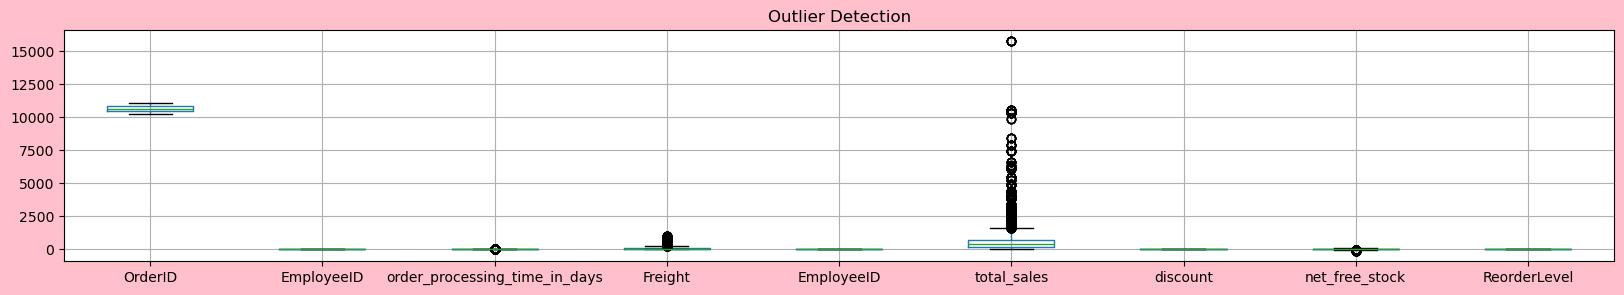

In [14]:
## checking for any outliers

plt.figure(figsize = (20,3), facecolor="pink")
df.boxplot()
plt.grid(True)
plt.title("Outlier Detection")
plt.show()

In [15]:
## dealing with outliers in the total sales column 

q1 = df["total_sales"].quantile(0.25) 
q3 = df["total_sales"].quantile(0.75)

iqr = q3 - q1 # interquartile range

upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)

df.loc[(df["total_sales"] > upper_limit ) | (df["total_sales"] < lower_limit)]

,CustomerID,OrderID,CompanyName,ContactName,ContactTitle,city,country,EmployeeID,order_processing_time_in_days,Freight,...,employee_region,TerritoryDescription,total_sales,discount,ProductName,net_free_stock,ReorderLevel,Discontinued,RegionDescription,shipper
239,AROUT,10953.0,Around the Horn,Thomas Hardy,Sales Representative,London,UK,9.0,9.0,23.72,...,None,Hollis ...,4050.0,0.05,Sir Rodney's Marmalade,40.0,0.0,False,Northern ...,United Package
241,AROUT,10953.0,Around the Horn,Thomas Hardy,Sales Representative,London,UK,9.0,9.0,23.72,...,None,Portsmouth ...,4050.0,0.05,Sir Rodney's Marmalade,40.0,0.0,False,Northern ...,United Package
243,AROUT,10953.0,Around the Horn,Thomas Hardy,Sales Representative,London,UK,9.0,9.0,23.72,...,None,Southfield ...,4050.0,0.05,Sir Rodney's Marmalade,40.0,0.0,False,Northern ...,United Package
245,AROUT,10953.0,Around the Horn,Thomas Hardy,Sales Representative,London,UK,9.0,9.0,23.72,...,None,Troy ...,4050.0,0.05,Sir Rodney's Marmalade,40.0,0.0,False,Northern ...,United Package
247,AROUT,10953.0,Around the Horn,Thomas Hardy,Sales Representative,London,UK,9.0,9.0,23.72,...,None,Bloomfield Hills ...,4050.0,0.05,Sir Rodney's Marmalade,40.0,0.0,False,Northern ...,United Package
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9848,WHITC,11032.0,White Clover Markets,Karl Jablonski,Owner,Seattle,USA,2.0,6.0,606.19,...,WA,Louisville ...,6587.5,0.00,Côte de Blaye,17.0,15.0,False,Eastern ...,Federal Shipping
9849,WHITC,11032.0,White Clover Markets,Karl Jablonski,Owner,Seattle,USA,2.0,6.0,606.19,...,WA,Louisville ...,1650.0,0.00,Raclette Courdavault,79.0,0.0,False,Eastern ...,Federal Shipping
9963,WHITC,10344.0,White Clover Markets,Karl Jablonski,Owner,Seattle,USA,4.0,4.0,23.29,...,WA,Rockville ...,2240.0,0.25,Northwoods Cranberry Sauce,6.0,0.0,False,Eastern ...,United Package
9965,WHITC,10344.0,White Clover Markets,Karl Jablonski,Owner,Seattle,USA,4.0,4.0,23.29,...,WA,Greensboro ...,2240.0,0.25,Northwoods Cranberry Sauce,6.0,0.0,False,Eastern ...,United Package


In [16]:
## dealing with the outliers

data = df.loc[(df["total_sales"] < upper_limit ) & (df["total_sales"] > lower_limit)]

print("Outliers:", len(df) - len(data))

Outliers: 777


In [17]:
## removing unwanted columns

data = data.drop(columns = ["EmployeeID"])

In [18]:
## adding columns

## adding the employee age column
from datetime import datetime

data["Employee Age"] = ((datetime(1997,12,31) - data["BirthDate"]).dt.days//365.25).astype(int) #dt.days//365.25 converts the result to years
data["Employee Age"]

# n/b .dt. accessor in Pandas lets you extract specific components from datetime-like or timedelta-like values.
# e.g .dt.days means Take the difference between the reference date and each birthdate, then return the number of days in that difference

0        34
1        34
2        34
3        34
4        34
         ..
10126    34
10127    49
10128    49
10129    49
10130    49
Name: Employee Age, Length: 9235, dtype: int32

In [19]:
## adding the employee tenure column

data["Employee Tenure"] = abs(((datetime(1979,12,31) - data["HireDate"]).dt.days // 365.25)).astype(int)
data["Employee Tenure"]

0        14
1        14
2        14
3        14
4        14
         ..
10126    14
10127    13
10128    13
10129    13
10130    13
Name: Employee Tenure, Length: 9235, dtype: int32

In [20]:
## employee status

data["Employee Status"] = np.where(data["Employee Age"] >= 60, "retired", "active")

### Exploratory Data Analysis

In [21]:
## summary statistics

data.describe()

,OrderID,order_processing_time_in_days,Freight,BirthDate,HireDate,total_sales,discount,net_free_stock,ReorderLevel,Employee Age,Employee Tenure
count,9235.000000,8963.000000,9235.000000,9235,9235,9235.000000,9235.000000,9235.000000,9235.000000,9235.000000,9235.000000
mean,10661.327991,8.346089,87.046697,1955-10-22 23:15:33.622089920,1993-05-26 07:49:20.693015680,429.422277,0.056322,31.538928,12.231727,41.587981,13.991879
min,10248.000000,1.000000,0.020000,1937-09-19 00:00:00,1992-04-01 00:00:00,4.800000,0.000000,-96.000000,0.000000,31.000000,13.000000
25%,10458.000000,4.000000,16.960000,1952-02-19 00:00:00,1992-08-14 00:00:00,145.600000,0.000000,10.000000,0.000000,34.000000,13.000000
50%,10657.000000,7.000000,47.940000,1958-01-09 00:00:00,1993-10-17 00:00:00,325.000000,0.000000,26.000000,10.000000,39.000000,14.000000
75%,10868.000000,9.000000,105.810000,1963-07-02 00:00:00,1994-01-02 00:00:00,600.000000,0.100000,61.000000,20.000000,45.000000,15.000000
max,11077.000000,37.000000,1007.640000,1966-01-27 00:00:00,1994-11-15 00:00:00,1600.000000,0.250000,125.000000,30.000000,60.000000,15.000000
std,240.772931,6.836001,119.620410,NaN,NaN,364.355335,0.083011,47.634388,10.737400,8.615102,0.845838


In [21]:
## more descriptive statistics

from scipy.stats import describe

numeric_data = data[["order_processing_time_in_days", "Freight","total_sales", "discount","net_free_stock","ReorderLevel"]]

description = describe(numeric_data)

for key, value in description._asdict().items():
    print(f"{key} : {value}")

nobs : 9235
minmax : (array([ 1.0e+00,  2.0e-02,  4.8e+00,  0.0e+00, -9.6e+01,  0.0e+00]), array([3.70000e+01, 1.00764e+03, 1.60000e+03, 2.50000e-01, 1.25000e+02,
       3.00000e+01]))
mean : [8.34725228e+00 8.70466973e+01 4.29422277e+02 5.63216035e-02
 3.15389280e+01 1.22317271e+01]
variance : [4.53544338e+01 1.43090424e+04 1.32754810e+05 6.89089737e-03
 2.26903495e+03 1.15291759e+02]
skewness : [2.10337091 3.38432625 1.21609326 1.17718762 0.08314802 0.25802827]
kurtosis : [ 4.44254848 15.56185332  0.91668706 -0.08155699 -0.10329704 -1.34357431]


#### KPIs

In [22]:
## total number of customers

print("Customers:", len(data["CustomerID"].unique()))

Customers: 89


In [23]:
## total number of orders

print("Orders:", len(data["OrderID"].unique()))

Orders: 821


In [24]:
## total sales

print("Total Sales:", data["total_sales"].sum().astype(int)) #astype(int) converts the end result to an integer

Total Sales: 3965714


In [25]:
## AVG Order Processing Days

print("AVG Order Processing Days:", data["order_processing_time_in_days"].mean().astype(int)) 

AVG Order Processing Days: 8


In [26]:
## AVG Employee age

print("AVG Order Processing Days:", data["order_processing_time_in_days"].mean().astype(int)) 

AVG Order Processing Days: 8


In [27]:
## AVG Employee Tenure

print("AVG Employee Tenure:", data["Employee Tenure"].mean().astype(int))

AVG Employee Tenure: 13


In [28]:
## employees

print("Employees:", len(data["employee_name"].unique()))

Employees: 9


##### Univariate Analysis

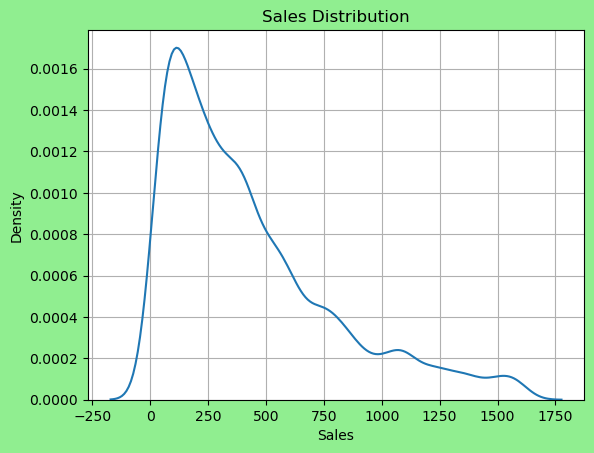

In [29]:
## total sales distribution

plt.figure(facecolor = "lightgreen", figure=(5,3))
sns.kdeplot(data=data, x="total_sales")
plt.xlabel("Sales")
plt.title("Sales Distribution")
plt.grid(True)
plt.show()

###### Interpretation : Sales is skewed to the left

C:\Users\Alvin\AppData\Local\Temp\ipykernel_6904\1940390201.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=data, x="Employee Age", hue="Employee Status")


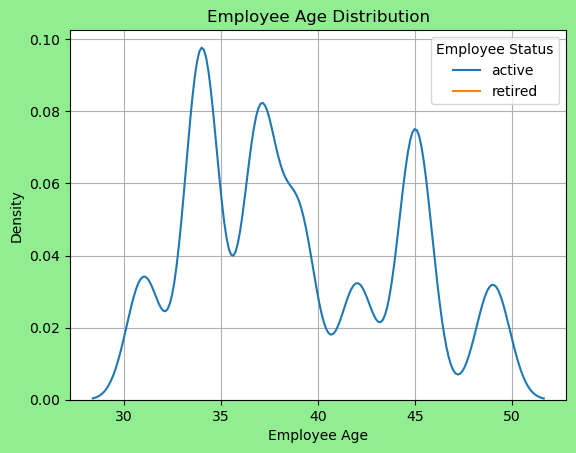

In [30]:
## Employee Tenure Distribution

plt.figure(facecolor = "lightgreen", figure=(5,2))
sns.kdeplot(data=data, x="Employee Age", hue="Employee Status")
plt.title("Employee Age Distribution")
plt.grid(True)
plt.show()

###### Interpretation: 

Employee Age has two peaks indicating that the organization currently employs people aged roughly 28 to 52, and none are at or above retirement age (60). The density curve shows which ages are most common among active employees—likely peaking around the mid-30s to early 40s.


##### Bivariate Analysis

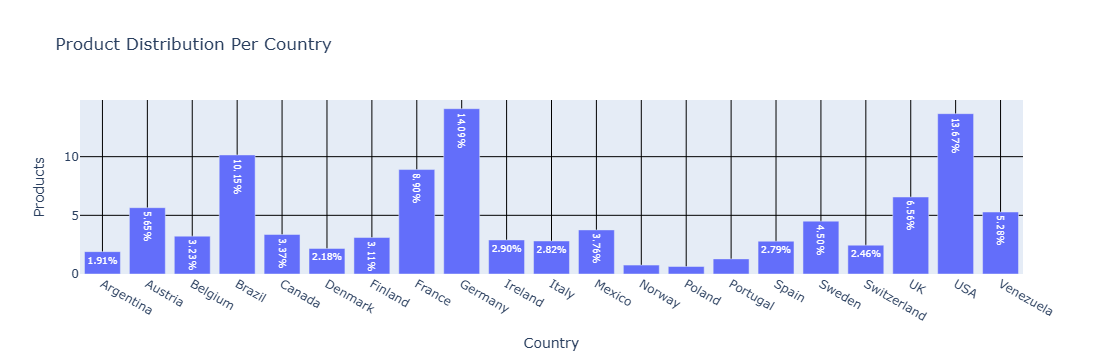

In [31]:
## products distribution per country

table = pd.pivot_table(data = data, index = "destination_country", values = "ProductName", aggfunc="count", sort="Descending")
table = table.rename(columns = {"ProductName" : "Products"}, index={"destination_country" : "Country"})
table["Products"] = (table["Products"] / table["Products"].sum())*100

# resetting the index
table = table.reset_index()

import plotly.express as px

# plotly bar chart
fig = px.bar(
    table,
    x="destination_country",
    y="Products",
    orientation="v",
    title="Product Distribution Per Country",
    text=table["Products"].apply(lambda x: f"{x:.2f}%")
)

fig.update_traces(
    textposition="inside",
    hovertemplate="%{x} : %{y:.2f}%"
)

fig.update_layout(
    xaxis=dict(
        title="Country",
        showgrid=True,
        gridcolor="black",
        zeroline=False
    ),
    yaxis=dict(
        title="Products",
        showgrid=True,
        gridcolor="black",
        zeroline=False
    ),
    uniformtext_minsize=8,
    uniformtext_mode="hide"
)

fig.show()

##### Interpretation:

1. Germany leads with 14.09% of exports with USA comes second as 13.67%.
2. Poland trails with 0.64% of products with Norway 0.76% trails with 0.76%.

##### Recommendation:

More products should be sold/supplied to higher performing nations to maximize revenue while targeted marketing campaigns from market research in lower demand - performing nations such as Poland and Norway to identify market gaps and update on customer preferences to increase sales in such areas.

#### Multivariate analysis

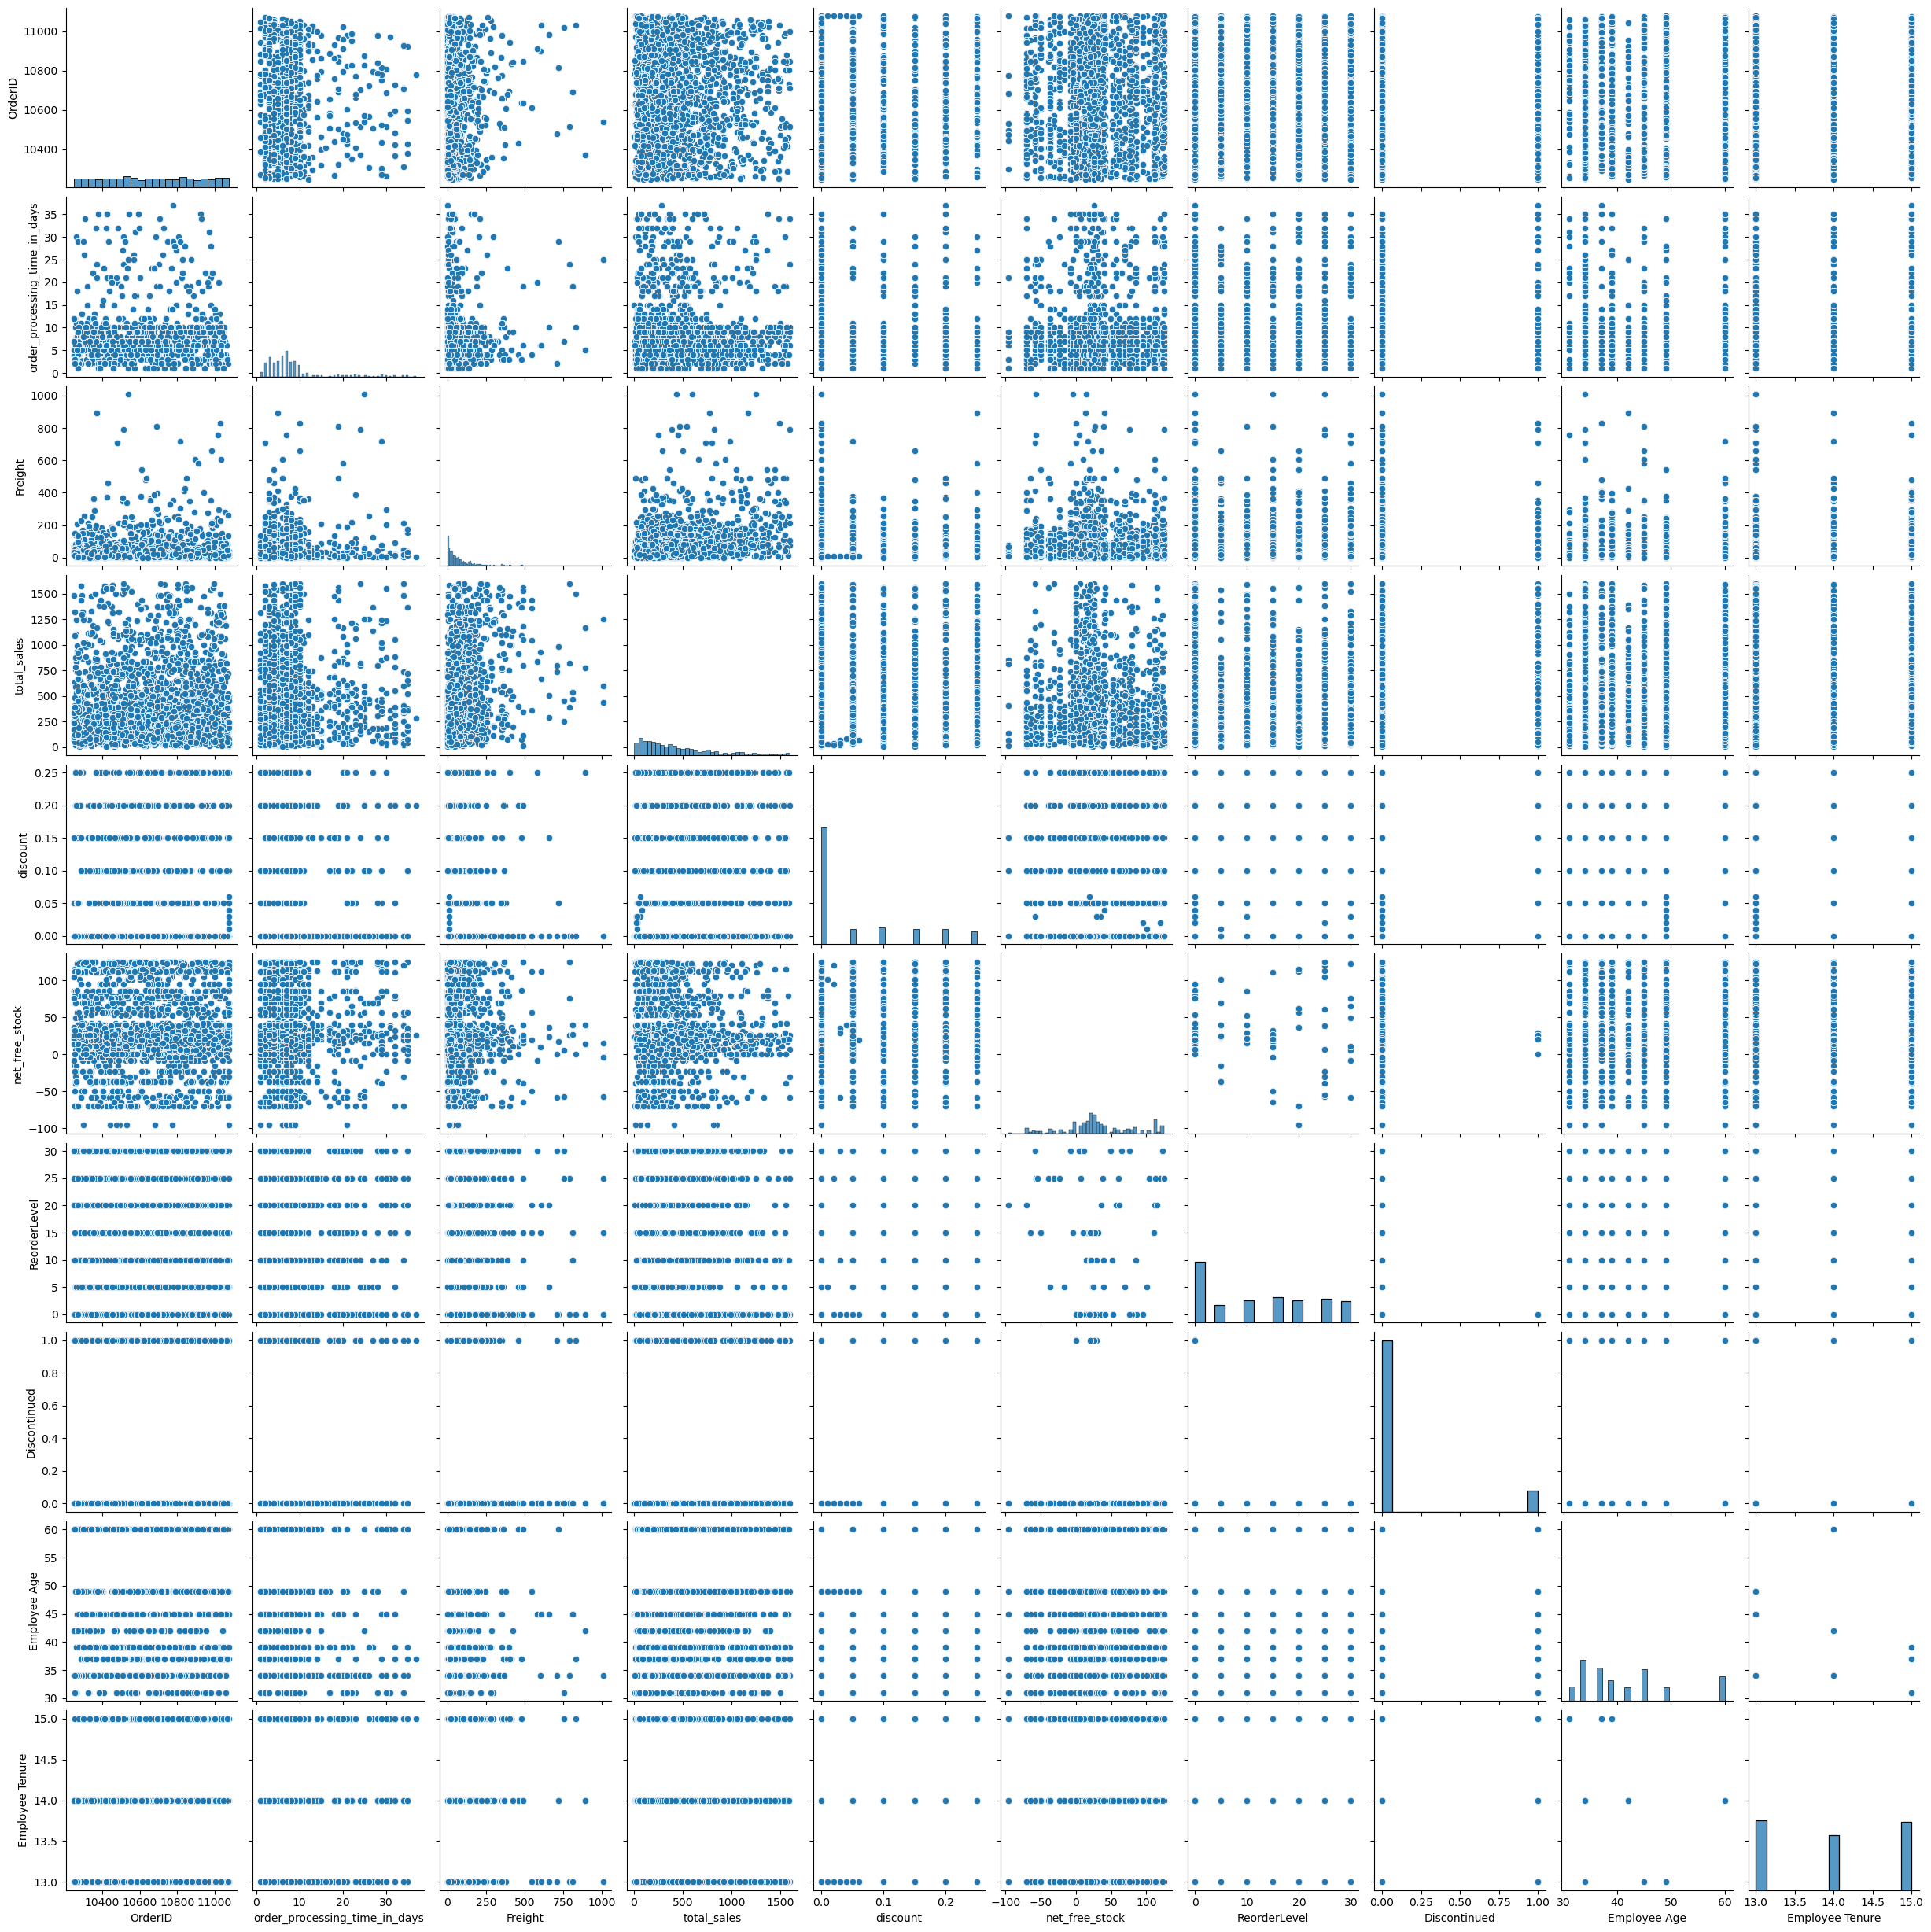

In [35]:
sns.pairplot(data)